#### Autor: David Roca Tauste

### EJERCICIO 12

In [1]:
# APARTADO A
# -*- coding: utf-8 -*-
import pandas as pd
from io import StringIO
import sys

csv_data = """A,B,C,D
1.0,2.0,3.0,4.0
5.0,6.0,,8.0
10.0,11.0,12.0,"""

# Si estás usando 2.7, necesitas convertirlo a string unicode
if sys.version_info < (3, 0):
    csv_data = csv_data.decode("utf-8")

df = pd.read_csv(StringIO(csv_data))
print(df)


# APARTADO B
# Borra una o varias columnas cuyo nombre se indica, si tienen valores ausentes.
print("\nSENTENCIA 1:")
resultado = df.dropna(subset=["C"])  # 1
print(resultado)

# Borra todas las filas donde todos los valores estén ausentes.
print("\nSENTENCIA 2:")
resultado = df.dropna(how="all")  # 2
print(resultado)

# Devuelve los arrays Numpy que contienen los datos del dataframe.
print("\nSENTENCIA 3:")
resultado = df.values  # 3
print(resultado)

# Borra las filas que contienen algún valor ausente.
print("\nSENTENCIA 4:")
resultado = df.dropna(axis=0)  # 4
print(resultado)

# Cuenta el número de valores ausentes que hay en cada columna / característica.
print("\nSENTENCIA 5:")
resultado = df.isnull().sum()  # 5
print(resultado)

# Borra las columnas que contienen algún valor ausente.
print("\nSENTENCIA 6:")
resultado = df.dropna(axis=1)  # 6
print(resultado)

# Borra las filas que tengan 3 o menos valores porque el resto están ausentes.
print("\nSENTENCIA 7:")
resultado = df.dropna(thresh=4)  # 7
print(resultado)


# APARTADO C
# Manera 1
print("\nDatos transformados\n", df.fillna(df.mean()))

# Manera 2
import numpy as np
from sklearn.impute import SimpleImputer

si = SimpleImputer(missing_values=np.nan, strategy='mean')
si = si.fit(df.values)
x = si.transform(df.values)

print("\nDatos originales\n", df.values)
print("\nDatos transformados\n", x)


      A     B     C    D
0   1.0   2.0   3.0  4.0
1   5.0   6.0   NaN  8.0
2  10.0  11.0  12.0  NaN

SENTENCIA 1:
      A     B     C    D
0   1.0   2.0   3.0  4.0
2  10.0  11.0  12.0  NaN

SENTENCIA 2:
      A     B     C    D
0   1.0   2.0   3.0  4.0
1   5.0   6.0   NaN  8.0
2  10.0  11.0  12.0  NaN

SENTENCIA 3:
[[ 1.  2.  3.  4.]
 [ 5.  6. nan  8.]
 [10. 11. 12. nan]]

SENTENCIA 4:
     A    B    C    D
0  1.0  2.0  3.0  4.0

SENTENCIA 5:
A    0
B    0
C    1
D    1
dtype: int64

SENTENCIA 6:
      A     B
0   1.0   2.0
1   5.0   6.0
2  10.0  11.0

SENTENCIA 7:
     A    B    C    D
0  1.0  2.0  3.0  4.0

Datos transformados
       A     B     C    D
0   1.0   2.0   3.0  4.0
1   5.0   6.0   7.5  8.0
2  10.0  11.0  12.0  6.0

Datos originales
 [[ 1.  2.  3.  4.]
 [ 5.  6. nan  8.]
 [10. 11. 12. nan]]

Datos transformados
 [[ 1.   2.   3.   4. ]
 [ 5.   6.   7.5  8. ]
 [10.  11.  12.   6. ]]


---
### EJERCICIO 13

In [2]:
# APARTADO A
import pandas as pd
import numpy as np

df = pd.DataFrame(
    [
        ["verde", "M", 10.1, "clase2"],
        ["rojo", "L", 13.5, "clase1"],
        ["azul", "XL", 15.3, "clase2"],
    ]
)
df.columns = ["color", "talla", "precio", "class"]

# APARTADO B
mapeo = {label: idx for idx, label in enumerate(np.unique(df["class"]))}
mapeo_inverso = {v: k for k, v in mapeo.items()}

# Hacer la transformación
df["class"] = df["class"].map(mapeo)
print("\nDataframe transformado:\n", df)

# Deshacer la transformación
df['class'] = df['class'].map(mapeo_inverso)
print("\nDataframe restaurado:\n", df)


# APARTADO C
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df["class"].values)

df['class'] = y
print("\nDataframe transformado con LabelEncoder:\n", df)

df['class'] = le.inverse_transform(df['class'])
print("\nDataframe restaurado con LabelEncoder:\n", df)


Dataframe transformado:
    color talla  precio  class
0  verde     M    10.1      1
1   rojo     L    13.5      0
2   azul    XL    15.3      1

Dataframe restaurado:
    color talla  precio   class
0  verde     M    10.1  clase2
1   rojo     L    13.5  clase1
2   azul    XL    15.3  clase2

Dataframe transformado con LabelEncoder:
    color talla  precio  class
0  verde     M    10.1      1
1   rojo     L    13.5      0
2   azul    XL    15.3      1

Dataframe restaurado con LabelEncoder:
    color talla  precio   class
0  verde     M    10.1  clase2
1   rojo     L    13.5  clase1
2   azul    XL    15.3  clase2


---
### EJERCICIO 14

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df = pd.DataFrame(
    [
        ["verde", "M", 10.1, "clase2"],
        ["rojo", "L", 13.5, "clase1"],
        ["azul", "XL", 15.3, "clase2"],
    ]
)
df.columns = ["color", "talla", "precio", "class"]

# # APARTADO A: Transformar la columna 'color' usando LabelEncoder
X = df[["color", "talla", "precio"]].values
le = LabelEncoder()
X[:, 0] = le.fit_transform(X[:, 0])
print("X transformado con LabelEncoder:\n", X)

# # APARTADO B: Ahora usando OneHotEncoder
ohe = OneHotEncoder()
X = ohe.fit_transform(df[["color", "talla", "precio"]])
print("\nX transformado con OneHotEncoder:\n", X)

# APARTADO C: Usar get_dummies() para obtener un nuevo dataframe añadiendo nuevas columnas
df_dummies = pd.get_dummies(df, columns=["color", "talla", "class"])
print("\nDataframe con get_dummies (sin drop_first):\n", df_dummies)

# APARTADO D: Usar get_dummies() con drop_first=True
df_dummies = pd.get_dummies(df, columns=["color", "talla", "class"], drop_first=True)
print("\nDataframe con get_dummies (con drop_first):\n", df_dummies)


X transformado con LabelEncoder:
 [[2 'M' 10.1]
 [1 'L' 13.5]
 [0 'XL' 15.3]]

X transformado con OneHotEncoder:
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9 stored elements and shape (3, 9)>
  Coords	Values
  (0, 2)	1.0
  (0, 4)	1.0
  (0, 6)	1.0
  (1, 1)	1.0
  (1, 3)	1.0
  (1, 7)	1.0
  (2, 0)	1.0
  (2, 5)	1.0
  (2, 8)	1.0

Dataframe con get_dummies (sin drop_first):
    precio  color_azul  color_rojo  color_verde  talla_L  talla_M  talla_XL  \
0    10.1       False       False         True    False     True     False   
1    13.5       False        True        False     True    False     False   
2    15.3        True       False        False    False    False      True   

   class_clase1  class_clase2  
0         False          True  
1          True         False  
2         False          True  

Dataframe con get_dummies (con drop_first):
    precio  color_rojo  color_verde  talla_M  talla_XL  class_clase2
0    10.1       False         True     True     False 

---
### EJERCICIO 15

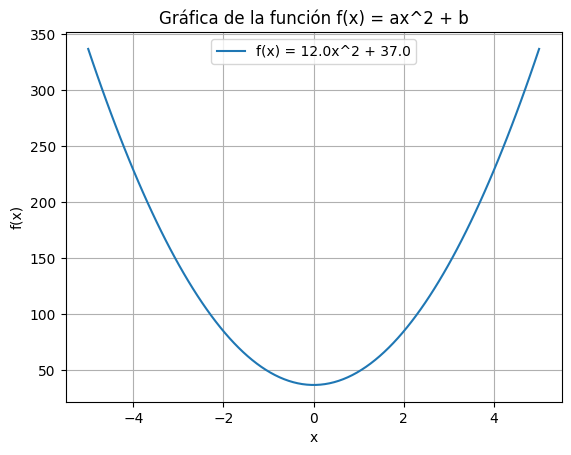

In [5]:
import numpy as np
import matplotlib.pyplot as plt

a = float(input("Introduce el valor de a: "))
b = float(input("Introduce el valor de b: "))

x = np.linspace(-5, 5, 100)
fx = a * x**2 + b

plt.plot(x, fx, label=f'f(x) = {a}x^2 + {b}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gráfica de la función f(x) = ax^2 + b')
plt.grid(True)
plt.legend()
plt.show()


---
### EJERCICIO 16

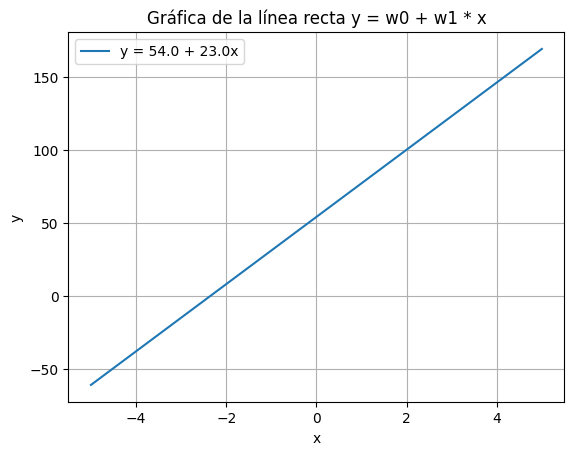

In [6]:
import numpy as np
import matplotlib.pyplot as plt

w0 = float(input("Introduce el valor de w0 (punto de corte): "))
w1 = float(input("Introduce el valor de w1 (pendiente): "))

x = np.linspace(-5, 5, 100)
y = w0 + w1 * x

plt.plot(x, y, label=f'y = {w0} + {w1}x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gráfica de la línea recta y = w0 + w1 * x')
plt.grid(True)
plt.legend()
plt.show()


---
### EJERCICIO 17

Cuadrado de las distancias: [0.0225 0.01   0.04   0.0025]

Porcentaje de error medio producido: 0.07500000000000001
Nuevo porcentaje de error medio producido: 0.10559999999999997

Valores óptimos:
w0 = 0.2859649122807015
w1 = 0.043859649122807015


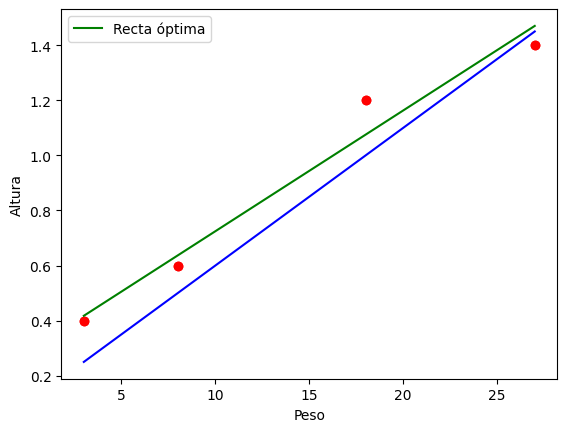

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# APARTADO A: Crear un Dataframe con los datos
datos = [[3, 0.4], [8, 0.6], [18, 1.2], [27, 1.4]]
df = pd.DataFrame(datos, columns=["Peso", "Altura"])

# APARTADO B: Dibujar un Scatterplot con círculos rojos, dejando el peso en el eje X y la altura en el eje Y
plt.scatter(df["Peso"], df["Altura"], color="red")
plt.xlabel("Peso")
plt.ylabel("Altura")
# plt.show() # Está comentado para que no aparezcan los 3 gráficos a la vez

# APARTADO C: Preguntar por el punto de corte (w0) y la pendiente de una recta (w1)
w0, w1 = 0.1, 0.05  # Estos valores son de ejemplo

# APARTADO D: Dibujar la recta en el gráfico con color azul
x = np.array(df["Peso"])
y = w0 + w1 * x
plt.plot(x, y, color="blue")
# plt.show() # Está comentado para que no aparezcan los 3 gráficos a la vez

# APARTADO E: Calcular e imprimir el cuadrado de la distancia de cada punto de datos
distancias = (df["Altura"] - (w0 + w1 * df["Peso"])) ** 2
print("Cuadrado de las distancias:", distancias.values)

# APARTADO F: Calcular la media de la suma de los cuadrados de esas diferencias
media_diferencias = np.mean(np.sum(distancias))
print("\nPorcentaje de error medio producido:", media_diferencias)

# APARTADO G: Minimizar el error ajustando w0 y w1
w0, w1 = 0.2, 0.04  # Estos valores son de prueba
y = w0 + w1 * x
distancias = (df["Altura"] - (w0 + w1 * df["Peso"])) ** 2
media_diferencias = np.mean(np.sum(distancias))
print("Nuevo porcentaje de error medio producido:", media_diferencias)

# APARTADO H: Usar la fórmula para calcular los valores óptimos de w0 y w1
# Añadir una columna de unos en los datos X
X = np.hstack((np.ones((df.shape[0], 1)), df[["Peso"]].values))
y = df["Altura"].values.reshape(-1, 1)

# Calcular W usando la fórmula
W = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
w0, w1 = W[0, 0], W[1, 0]
print("\nValores óptimos:")
print("w0 =", w0)
print("w1 =", w1)

# Dibujar la recta óptima en el gráfico final
plt.scatter(df["Peso"], df["Altura"], color="red")
plt.plot(x, w0 + w1 * x, color="green", label="Recta óptima")
plt.xlabel("Peso")
plt.ylabel("Altura")
plt.legend()
plt.show()

---
### EJERCICIO 18

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# APARTADO A: Crear Dataframe a partir del fichero
df = pd.read_csv("mpg.csv")

print("Dataframe original:")
print(df.head())

# APARTADO B: Eliminar la columna "nombre"
if "nombre" in df.columns:    # Esto es por si no estuviera la columna. En este caso no hace falta
    df = df.drop(columns=["nombre"])
    print("\nDataframe sin la columna 'nombre':")
    print(df.head())

# APARTADO C: Hacer una versión escalada en [0,1] de los datos
df_escalado = df.copy()
for columna in df_escalado.columns:
    minimo = df_escalado[columna].min()
    maximo = df_escalado[columna].max()
    df_escalado[columna] = (df_escalado[columna] - minimo) / (
        maximo - minimo
    )

print("\nDataframe escalado en [0,1]:")
print(df_escalado.head())

# APARTADO D: Hacer lo mismo con MinMaxScaler de sklearn.preprocessing
scaler = MinMaxScaler()
df_escalado_sklearn = df.copy()
columnas = df_escalado_sklearn.columns
df_escalado_sklearn[columnas] = scaler.fit_transform(
    df_escalado_sklearn[columnas]
)

print("\nDataframe escalado con MinMaxScaler en [0,1]:")
print(df_escalado_sklearn.head())

# Los head() no son necesarios. Son para mostrar solamente las 5 primeras filas

Dataframe original:
    mpg  cilindros  desplazamiento  potenciaCV  peso  aceleracion  \
0  18.0          8           307.0         130  3504         12.0   
1  15.0          8           350.0         165  3693         11.5   
2  18.0          8           318.0         150  3436         11.0   
3  16.0          8           304.0         150  3433         12.0   
4  17.0          8           302.0         140  3449         10.5   

   modelo_year  origen                     nombre  
0           70       1  chevrolet chevelle malibu  
1           70       1          buick skylark 320  
2           70       1         plymouth satellite  
3           70       1              amc rebel sst  
4           70       1                ford torino  

Dataframe sin la columna 'nombre':
    mpg  cilindros  desplazamiento  potenciaCV  peso  aceleracion  \
0  18.0          8           307.0         130  3504         12.0   
1  15.0          8           350.0         165  3693         11.5   
2  18.0   

---
### EJERCICIO 19

Dataframe sin la columna 'nombre':
    mpg  cilindros  desplazamiento  potenciaCV  peso  aceleracion  \
0  18.0          8           307.0         130  3504         12.0   
1  15.0          8           350.0         165  3693         11.5   
2  18.0          8           318.0         150  3436         11.0   
3  16.0          8           304.0         150  3433         12.0   
4  17.0          8           302.0         140  3449         10.5   

   modelo_year  origen  
0           70       1  
1           70       1  
2           70       1  
3           70       1  
4           70       1  

Dataframe escalado:
        mpg  cilindros  desplazamiento  potenciaCV      peso  aceleracion  \
0 -0.705551   1.496308        1.089233    0.673102  0.630077    -1.293870   
1 -1.089379   1.496308        1.501624    1.542246  0.853259    -1.475181   
2 -0.705551   1.496308        1.194728    1.169756  0.549778    -1.656492   
3 -0.961437   1.496308        1.060461    1.169756  0.546236    -1.2938

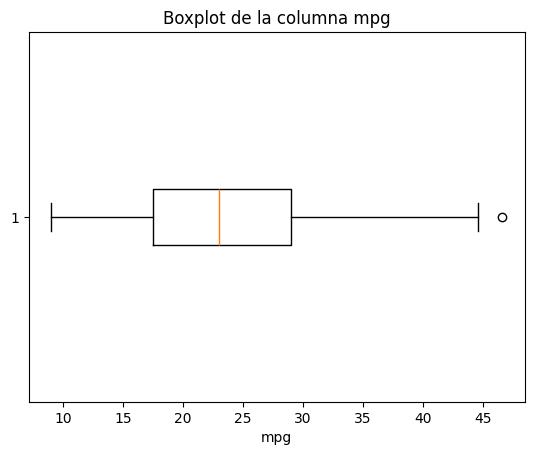

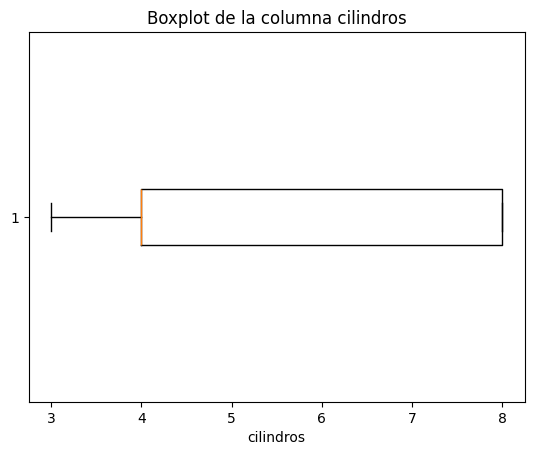

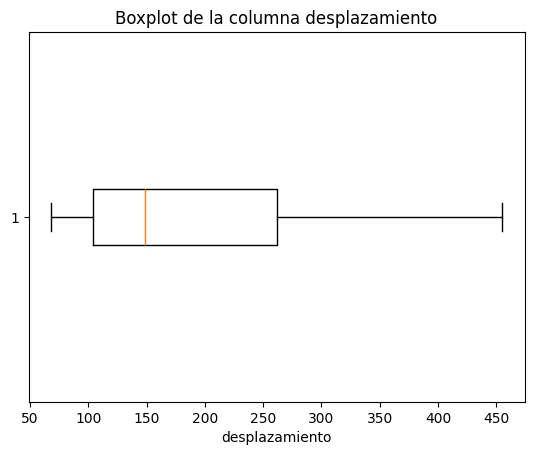

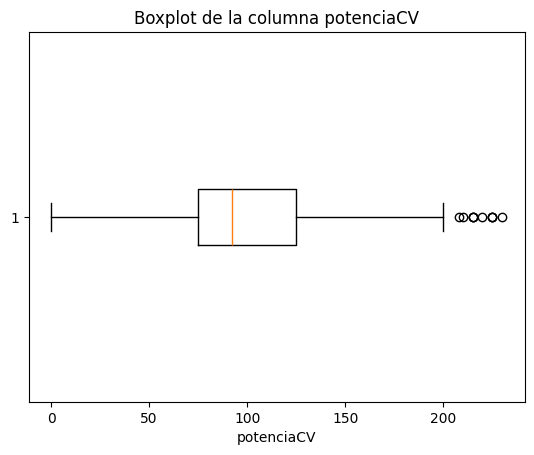

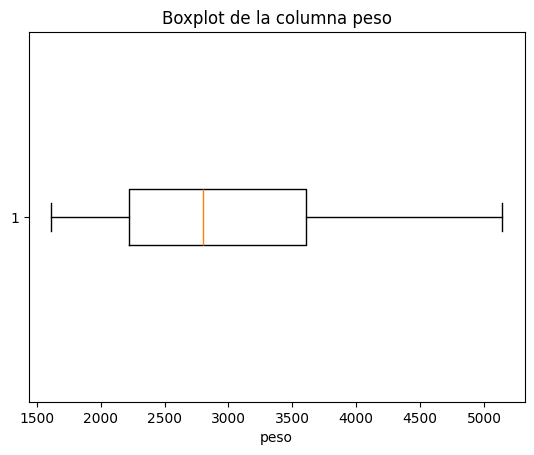

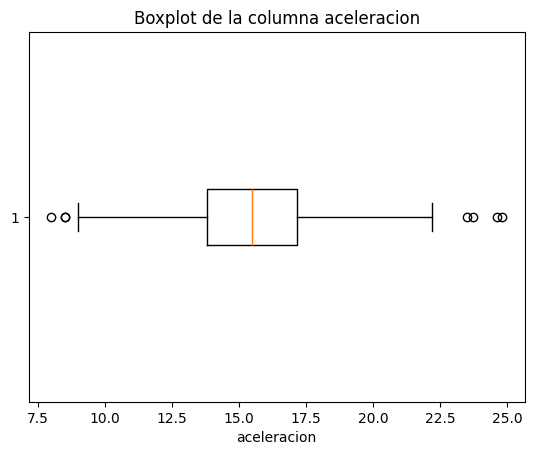

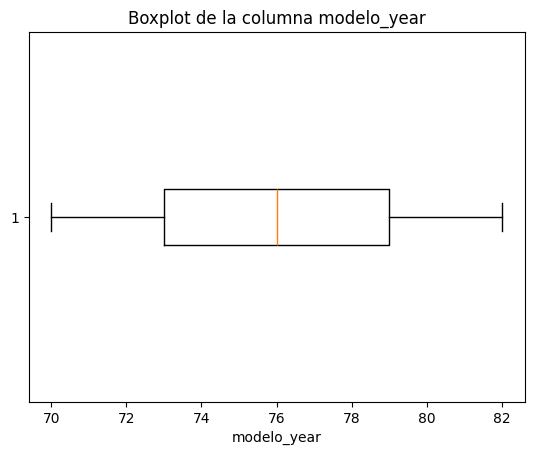

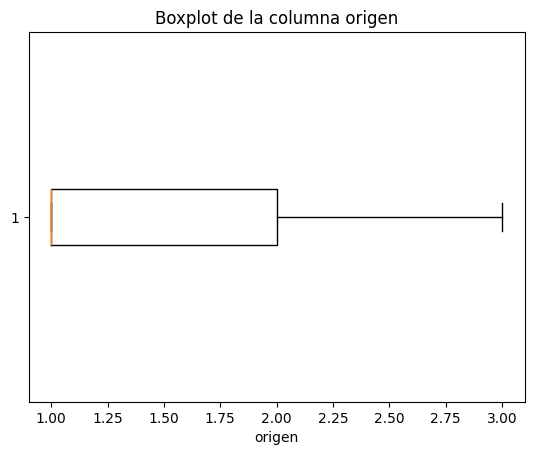

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# APARTADO A: Crear un Dataframe eliminando la columna "nombre"
df = pd.read_csv("mpg.csv")
if "nombre" in df.columns:
    df = df.drop(columns=["nombre"])
print("Dataframe sin la columna 'nombre':")
print(df.head())

# APARTADO B: Hacer una versión escalada normalizando los datos de las columnas
df_escalado = df.copy()
for columna in df_escalado.columns:
    media = df_escalado[columna].mean()
    desviacion = df_escalado[columna].std()
    df_escalado[columna] = (df_escalado[columna] - media) / desviacion

print("\nDataframe escalado:")
print(df_escalado.head())

# APARTADO C: Hacer lo mismo usando StandardScaler de sklearn.preprocessing
scaler = StandardScaler()
df_escalado_sklearn = df.copy()
columnas = df_escalado_sklearn.columns
df_escalado_sklearn[columnas] = scaler.fit_transform(df_escalado_sklearn[columnas])

print("\nDataFrame escalado con StandardScaler:")
print(df_escalado_sklearn.head())

# APARTADO D: Encontrar outliers usando el método de la mediana (IQR)
outliers_iqr = {}
for columna in df.columns:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_min = Q1 - 1.5 * IQR
    limite_max = Q3 + 1.5 * IQR
    outliers_iqr[columna] = df[(df[columna] < limite_min) | (df[columna] > limite_max)][columna]

print("\nOutliers encontrados usando el método de la mediana:")
for columna, outliers in outliers_iqr.items():
    print(f"{columna}: {outliers.values}")

# APARTADO E: Encontrar outliers usando z-scores
outliers_zscore = {}
for columna in df.columns:
    media = df[columna].mean()
    desviacion = df[columna].std()
    z_scores = (df[columna] - media) / desviacion
    outliers_zscore[columna] = df[columna][np.abs(z_scores) > 3]

print("\nOutliers encontrados usando z-scores:")
for columna, outliers in outliers_zscore.items():
    print(f"{columna}: {outliers.values}")

# APARTADO F: Detectar outliers dibujando boxplots de las columnas
for columna in df.columns:
    plt.figure()
    plt.boxplot(df[columna].dropna(), vert=False)
    plt.title(f"Boxplot de la columna {columna}")
    plt.xlabel(columna)
    plt.show()